## Cluster Quantification

Lead : `<Oscar Heath / baleinegris>`

Issue : Github Issue #51

Start : 2026-03-24

Complete : 2026-03-25

Files : 

~/resources/260324_issue51_clusterquantification/ — contains notebook of the whole process

~/notebooks/260324_issue51_clusterquantification.ipynb — the notebook write-up

S3 files :

s3://petadex/esm_embeddings/family_embeddings.npz — used embeddings that Dennis made

### Data Accessed: 2026-03-24

```bash 
# commands used to pull input data
aws s3 cp s3://petadex/esm_embeddings/family_embeddings.npz ./data/embeddings.npz`
```

### Introduction

Upon overlaying component information onto the UMAP atlas on petadex, we saw what appears to be strong clustering based on structural components. We aim to quantify these clusters using silhouette scores, which measure for each data point how well it fits its assigned cluster, taking into account its distance to other points in its own cluster and the distance to points in the next best alternative cluster:

$$SS_i = \frac{b_i - a_i}{min(a_i, b_i)}$$

Inter-Cluster Distance ($a_i$): Average distance between the sample and all other samples in the same cluster; smaller is better

Nearest-Cluster Distance ($b_i$): Average distance between the sample and all samples in the next best alternative cluster; larger is better

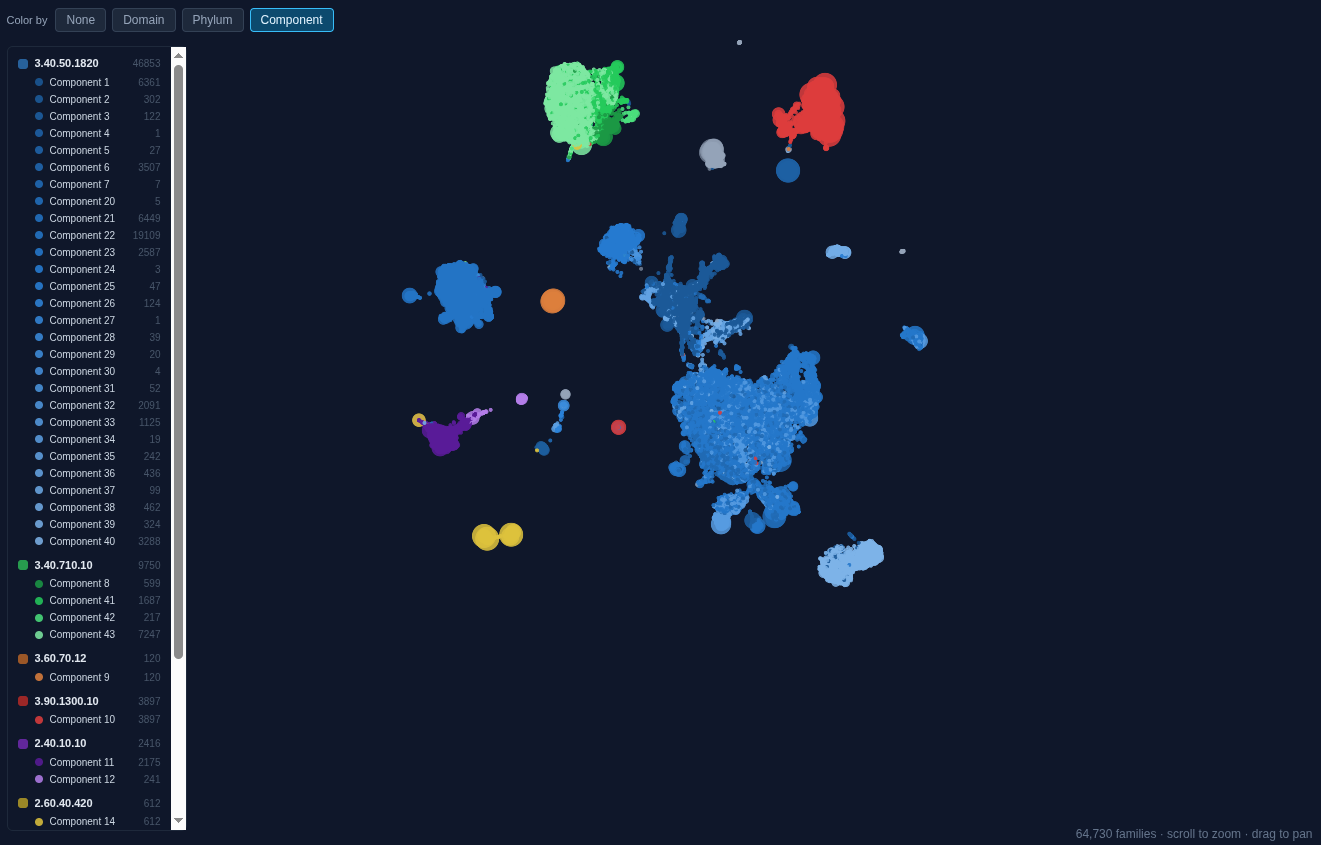

### Objectives:
- Calculate silhouette scores for the clusters formed using both domains and components
- Calculate silhouette scores for original embeddings in 640D space, as well as the 2D UMAP atlas points
- 4 plots total

### Methods and Materials

#### Data initialization

Embeddings were pulled from s3 using the script in `pull_data.sh`:
```bash
# Accessed: 2026-03-16
:~$./pull_data.sh
```

Additionally, I used the `family_atlas` table from the Postgres DB, as well as the `component.summary.tsv` file provided by Artem (used for prettier names for domains).

#### Silhouette Score calculation

I calculated silhouette scores using `scikit-learn 1.8.0`:

```python
from sklearn.metrics import silhouette_score, silhouette_samples
```
 and plotted them using pyplot from the `matplotlib 3.10.8` package. The whole process can be seen in `cluster_quantification.ipynb`. 
 
 I did not use sampling so no random seed was used.

 Additionally, I used cosine distance for component based calculations in 640D due to curse of dimensionality on large clusters, and euclidean distance everywhere else.

### Results & Discussion

Plots are shown here:

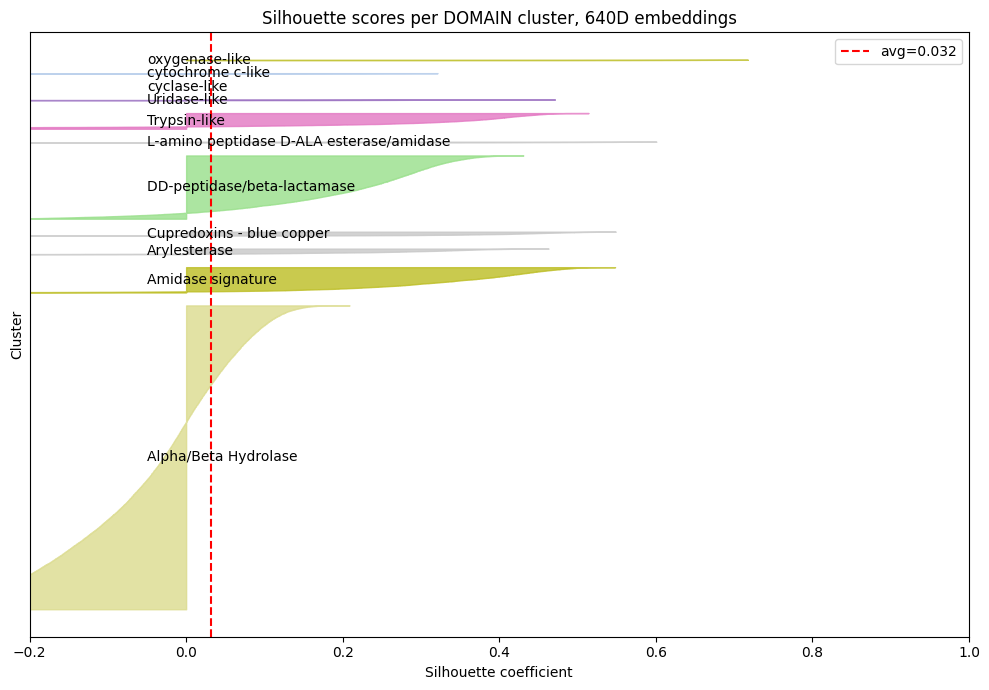

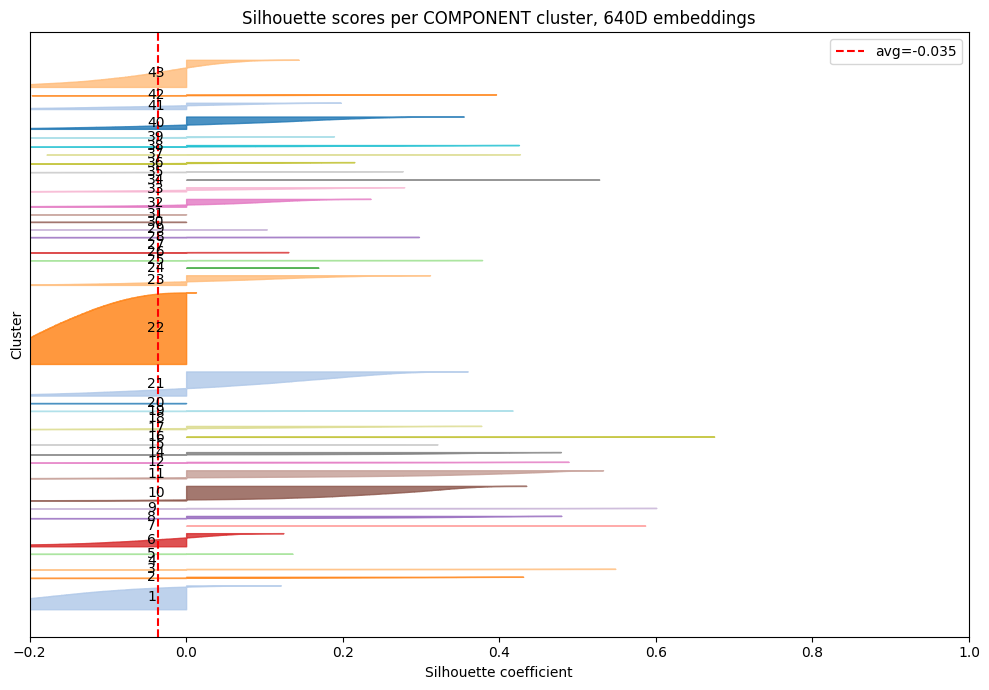

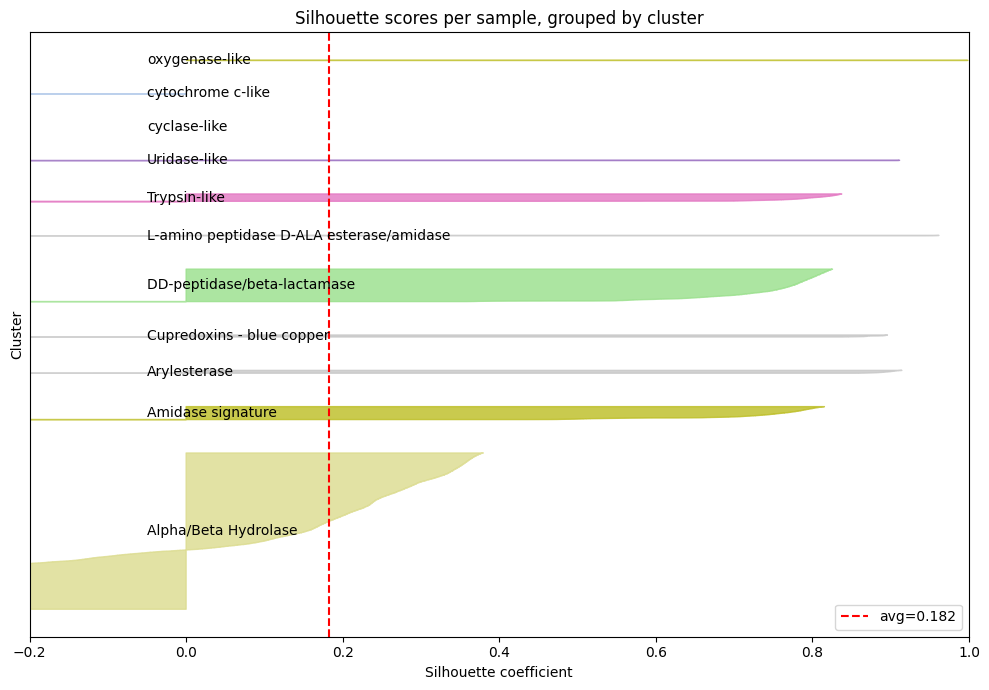

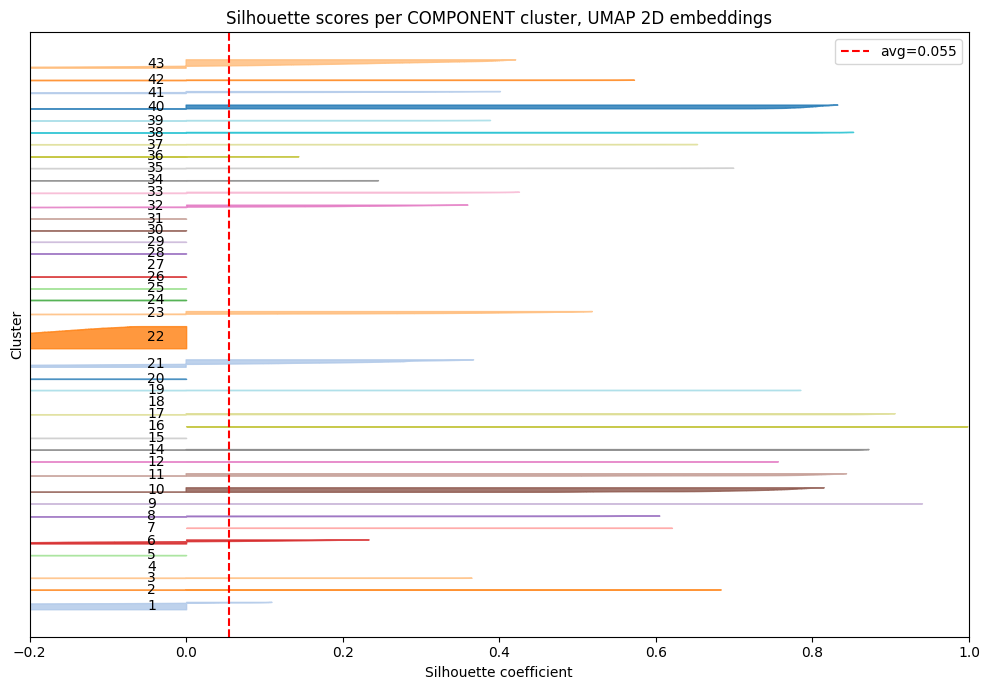

As the plots show, we definitely see clustering across all of the measurements. Recall that these are not clusters generated by any algorithm like K-means, these naturally formed in the ESM embeddings. 

